# ST_Convexhull(geom)

Create convex hull of given geometry.

In [1]:
import geofunctions as S
import geopandas as gp
import pyspark.sql.functions as F

In [13]:
data = [("MULTIPOINT (10 40, 40 30, 25 30, 30 10)",)]

In [14]:
df = spark.createDataFrame(data, "wkt string").select(
    S.st_fromtext("wkt").alias("geometry"),
    F.lit("red").alias("color")
)

In [15]:
ch = df.select(
    S.st_convexhull("geometry").alias("geometry"),
    F.lit("green").alias("color")
)

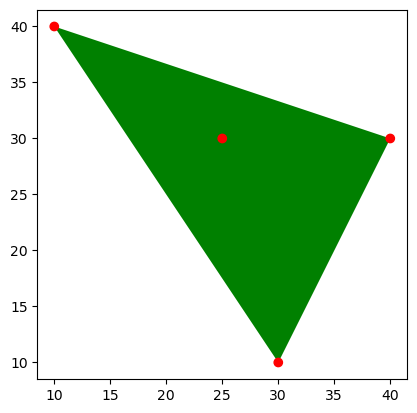

In [16]:
pdf = ch.unionAll(df).toPandas()
pdf.geometry = gp.GeoSeries.from_wkb(pdf.geometry)
gdf = gp.GeoDataFrame(pdf)
_ = gdf.plot(color=pdf.color)